2026-05-07 08:06:23.485121: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


正在加载 Sign Language MNIST 数据集...
测试集加载成功！形状: (7172, 785)
训练集加载成功！形状: (27455, 785)
标签映射: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}
训练集: 24709 样本
验证集: 2746 样本
测试集: 7172 样本


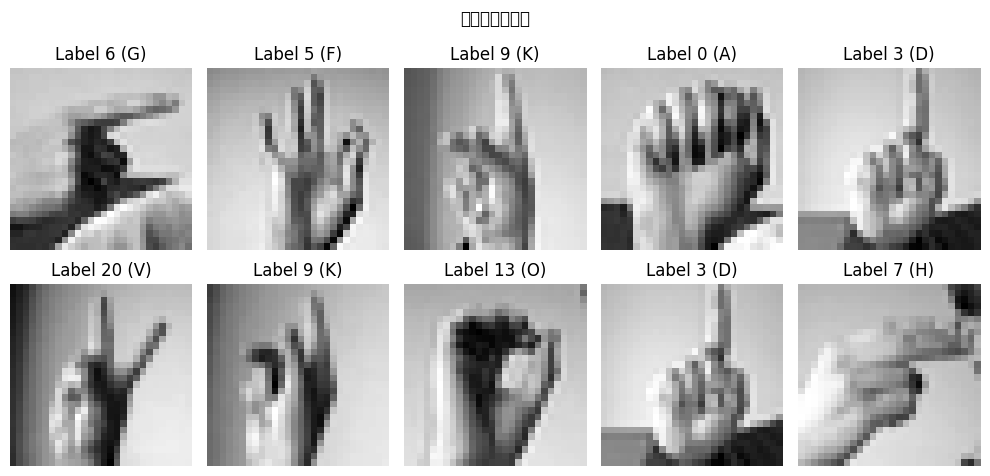

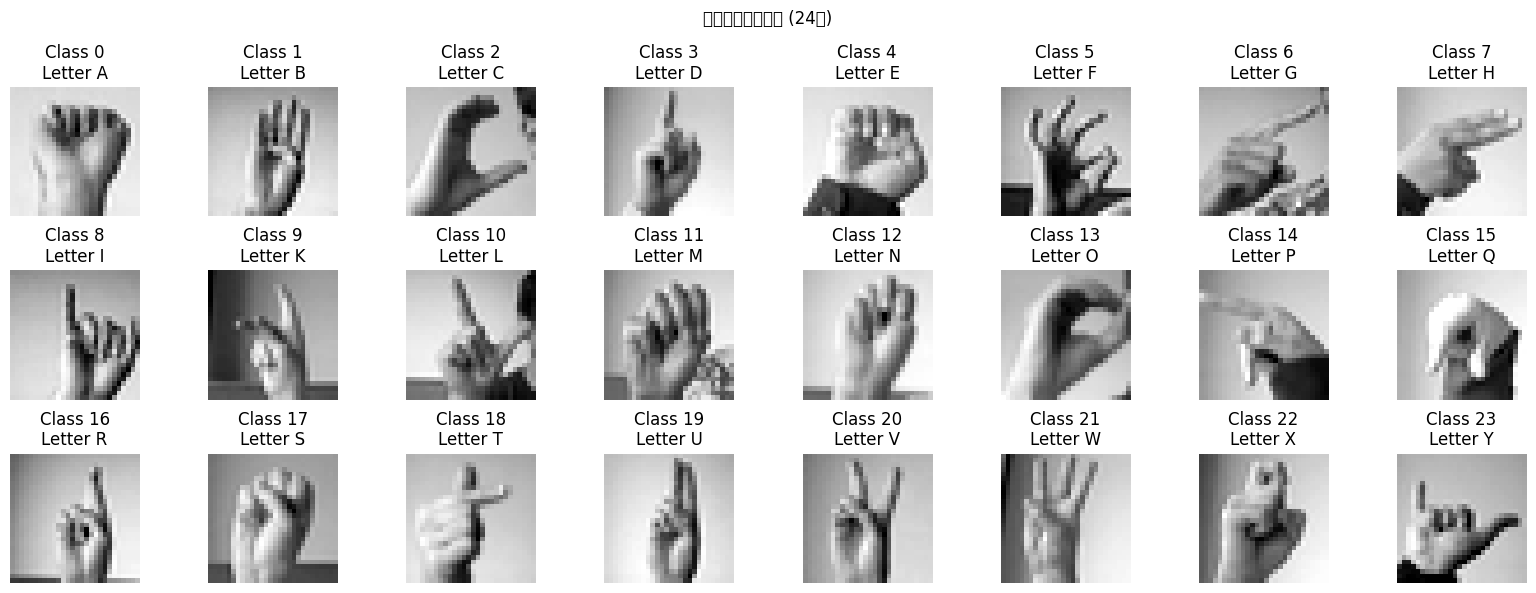

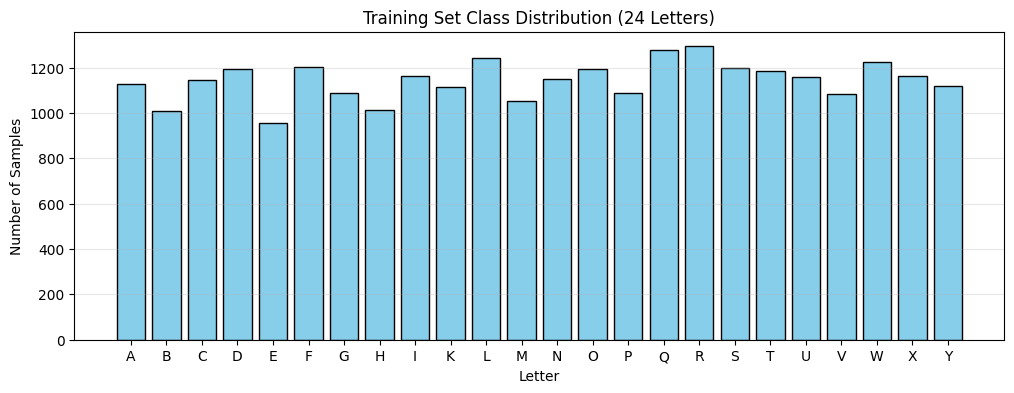


--- 超参数网格搜索 (基于简单CNN，epochs=8) ---
测试: lr=0.001, batch_size=32, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9734
测试: lr=0.001, batch_size=32, optimizer=sgd
  -> Val Acc: 0.9366, Train Acc: 0.7821
测试: lr=0.001, batch_size=64, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9584
测试: lr=0.001, batch_size=64, optimizer=sgd
  -> Val Acc: 0.7666, Train Acc: 0.5700
测试: lr=0.001, batch_size=128, optimizer=adam
  -> Val Acc: 0.9989, Train Acc: 0.9352
测试: lr=0.001, batch_size=128, optimizer=sgd
  -> Val Acc: 0.3638, Train Acc: 0.2589
测试: lr=0.0005, batch_size=32, optimizer=adam
  -> Val Acc: 1.0000, Train Acc: 0.9720
测试: lr=0.0005, batch_size=32, optimizer=sgd
  -> Val Acc: 0.7094, Train Acc: 0.5338
测试: lr=0.0005, batch_size=64, optimizer=adam
  -> Val Acc: 0.9989, Train Acc: 0.9393
测试: lr=0.0005, batch_size=64, optimizer=sgd
  -> Val Acc: 0.4454, Train Acc: 0.3183
测试: lr=0.0005, batch_size=128, optimizer=adam
  -> Val Acc: 0.9975, Train Acc: 0.9274
测试: lr=0.0005, batch_size=128, optimi

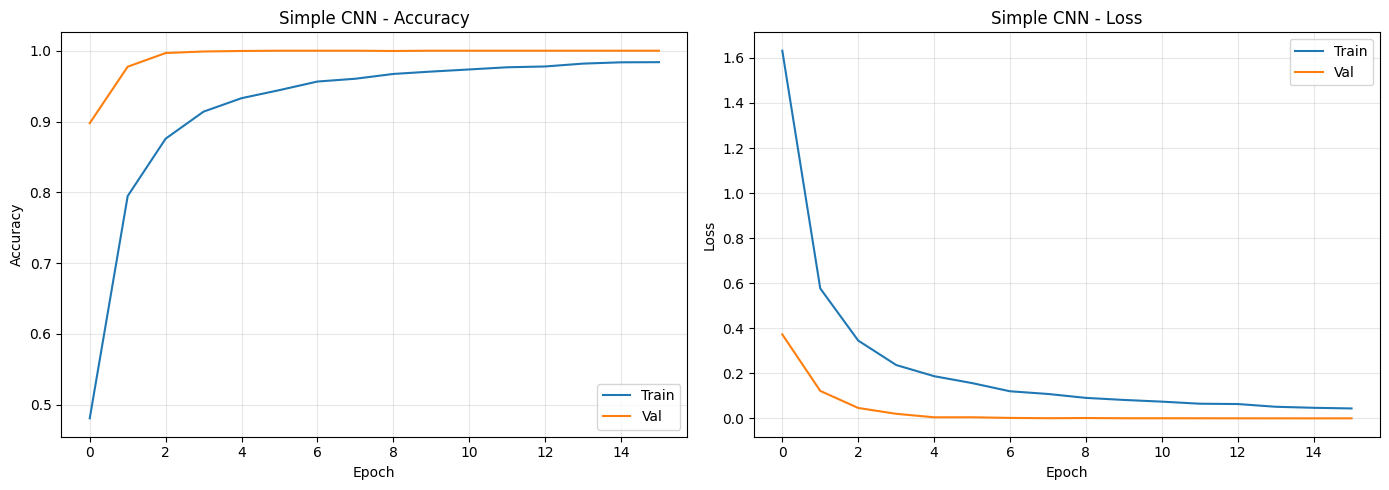


训练 VGG-Style CNN ...
Epoch 1/30
773/773 [==============================] - 30s 38ms/step - loss: 1.3675 - accuracy: 0.6006 - val_loss: 0.1049 - val_accuracy: 0.9803 - lr: 0.0010
Epoch 2/30
773/773 [==============================] - 29s 38ms/step - loss: 0.1988 - accuracy: 0.9432 - val_loss: 0.0074 - val_accuracy: 0.9975 - lr: 0.0010
Epoch 3/30
773/773 [==============================] - 29s 38ms/step - loss: 0.0808 - accuracy: 0.9781 - val_loss: 0.0145 - val_accuracy: 0.9949 - lr: 0.0010
Epoch 4/30
773/773 [==============================] - 29s 38ms/step - loss: 0.0422 - accuracy: 0.9893 - val_loss: 4.9077e-04 - val_accuracy: 0.9996 - lr: 0.0010
Epoch 5/30
773/773 [==============================] - 29s 38ms/step - loss: 0.0388 - accuracy: 0.9886 - val_loss: 9.1830e-05 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/30
773/773 [==============================] - 30s 38ms/step - loss: 0.0370 - accuracy: 0.9888 - val_loss: 1.7519e-04 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/30
773/773 [====

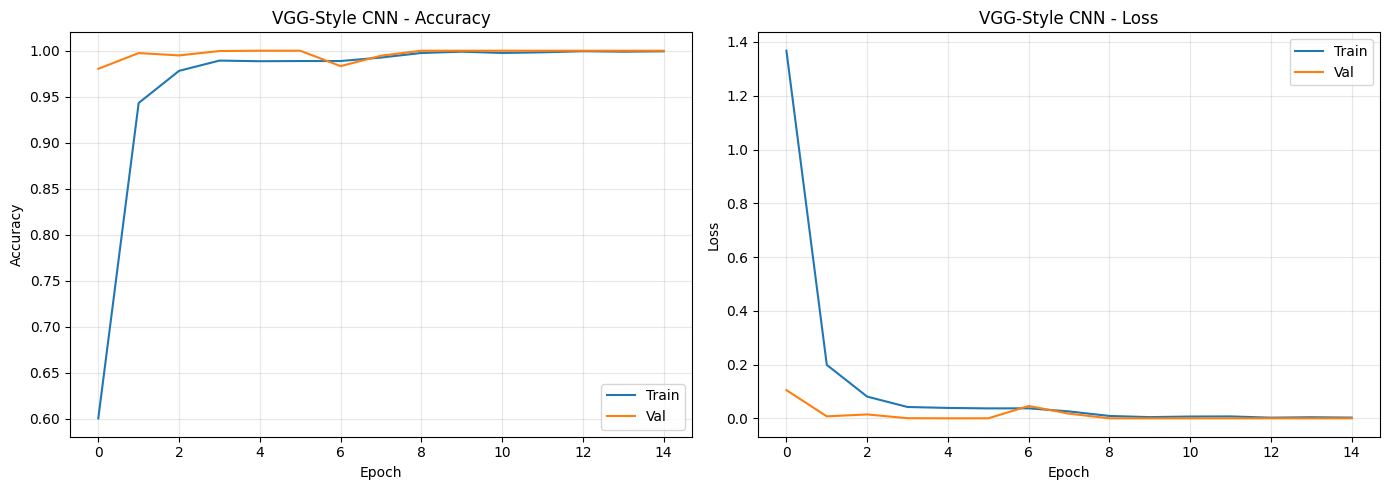


------------------------------------------------------------
模型性能对比
------------------------------------------------------------
模型                 测试准确率      测试损失       参数量          训练时间(秒)     
------------------------------------------------------------
Simple CNN         0.9260     0.2935     423,448      101.5       
VGG-Style CNN      0.9868     0.0288     620,920      442.0       

最佳模型: VGG-Style CNN (准确率 0.9868)

------------------------------------------------------------
详细评估最佳模型: VGG-Style CNN
------------------------------------------------------------


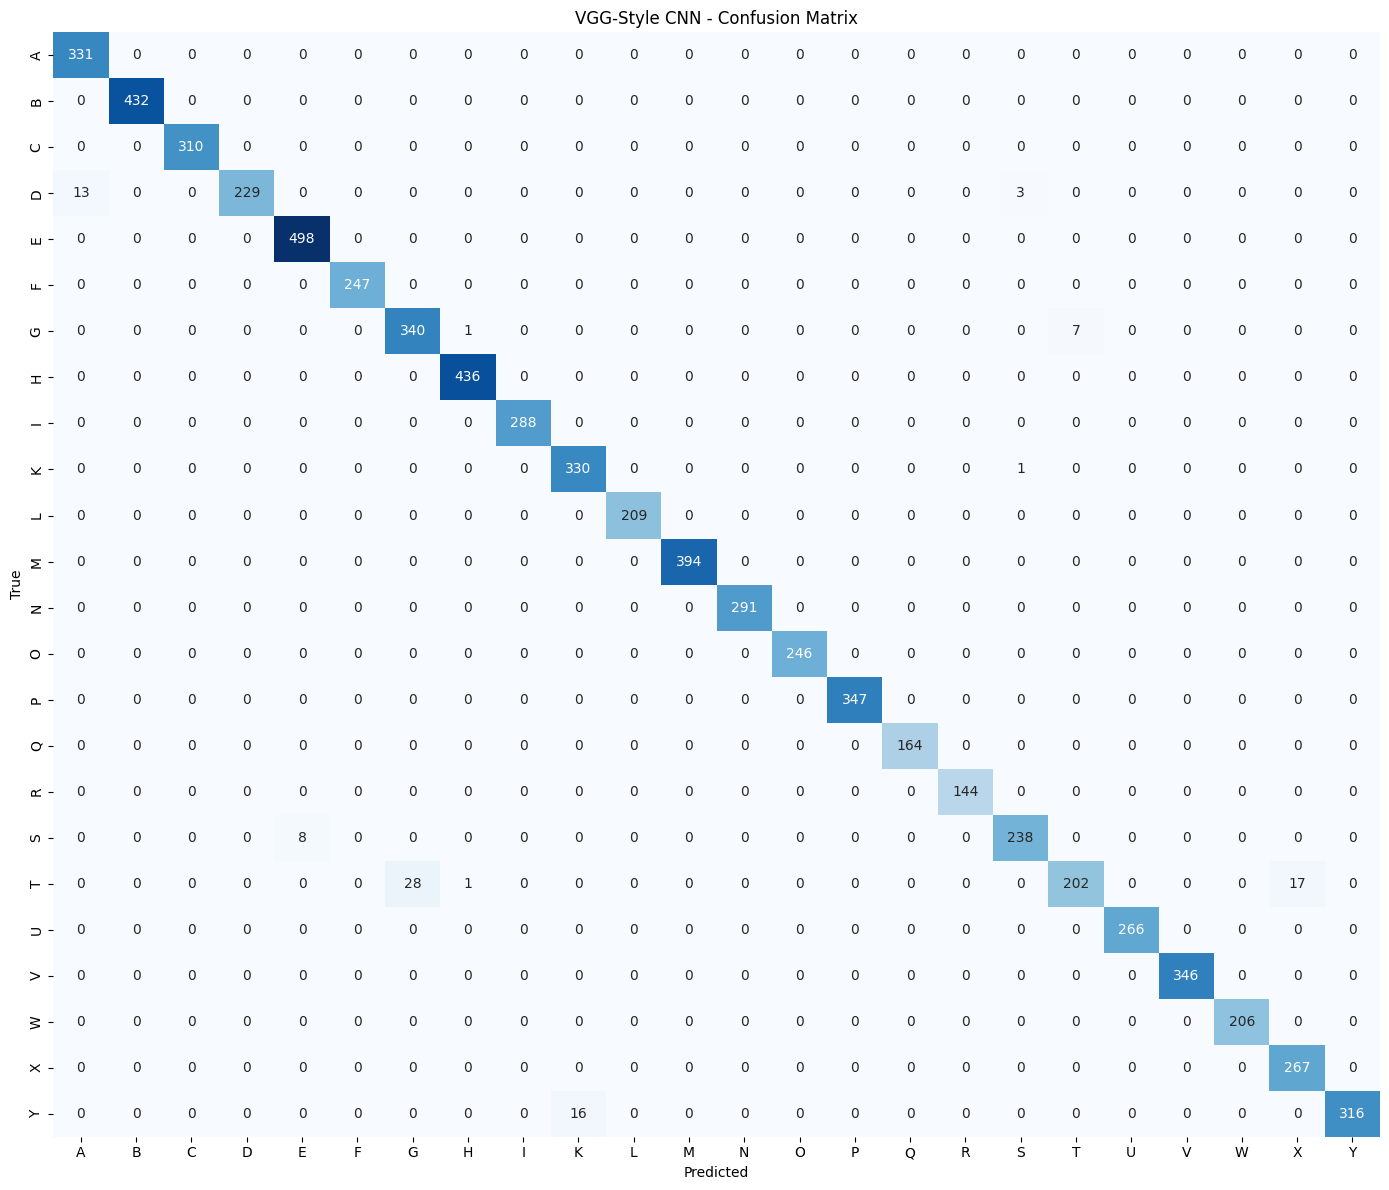


分类报告:
              precision    recall  f1-score   support

           A       0.96      1.00      0.98       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      0.93      0.97       245
           E       0.98      1.00      0.99       498
           F       1.00      1.00      1.00       247
           G       0.92      0.98      0.95       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       0.95      1.00      0.97       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00       144
           S       0

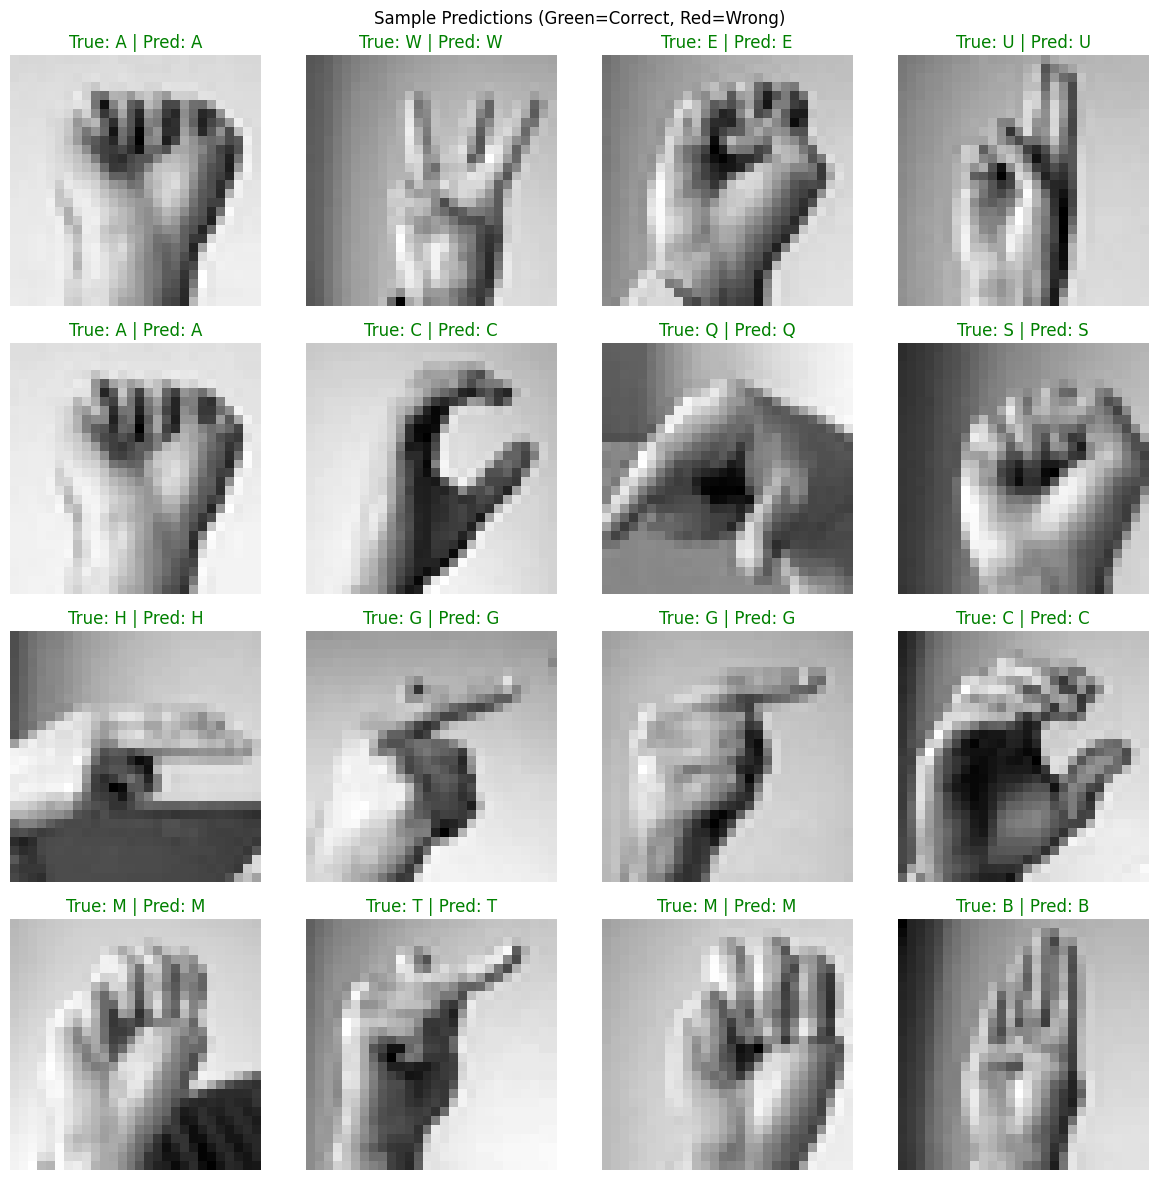


程序执行完毕！


In [1]:
# %% [markdown]
# # 基于深度卷积神经网络的手语识别
# ### Sign Language MNIST 数据集（A-Y，24类）
# 
# **项目结构：**
# 1. 数据加载与预处理（标签重映射、归一化、验证集划分）
# 2. 数据探索与可视化
# 3. 构建两种CNN模型（简单CNN 与 增强VGG风格CNN）
# 4. 训练、测试与评估（含超参数网格搜索、训练曲线、混淆矩阵、分类报告）
# 5. 样本预测可视化
# 
# **文件要求：**  
# - `sign_mnist_train.csv` 和 `sign_mnist_test.csv` 与本 notebook 在同一目录下

# %%
# 环境设置
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import time
import warnings
warnings.filterwarnings('ignore')

# 固定随机种子确保结果可复现
np.random.seed(42)
tf.random.set_seed(42)

# %%
# ==================== 1. 数据加载 ====================
print("正在加载 Sign Language MNIST 数据集...")

train_path = 'sign_mnist_train.csv'
test_path = 'sign_mnist_test.csv'

# 加载测试集（总是加载，用于预览和最终评估）
test_df = pd.read_csv(test_path) if os.path.exists(test_path) else None
if test_df is not None:
    print(f"测试集加载成功！形状: {test_df.shape}")
else:
    print(f"警告：未找到测试集文件 {test_path}")

# 加载训练集（如果存在）
train_df = pd.read_csv(train_path) if os.path.exists(train_path) else None
if train_df is not None:
    print(f"训练集加载成功！形状: {train_df.shape}")
else:
    print(f"警告：未找到训练集文件 {train_path}，将仅预览测试集。")

# %%
# ==================== 2. 数据预处理 ====================
if train_df is not None or test_df is not None:
    # 构建标签映射（基于已知数据集定义，排除 J 和 Z）
    known_labels = list(range(9)) + list(range(10, 25))  # 0-8,10-24
    label_map = {old: new for new, old in enumerate(known_labels)}
    reverse_label_map = {new: old for old, new in label_map.items()}
    num_classes = 24
    print(f"标签映射: {label_map}")
else:
    raise FileNotFoundError("至少需要测试集文件。")

def preprocess(df, label_map):
    """数据预处理：提取、映射、归一化、reshape"""
    y = df['label'].map(label_map).values
    X = df.drop('label', axis=1).values.astype('float32') / 255.0
    X = X.reshape(-1, 28, 28, 1)
    y_cat = to_categorical(y, num_classes=num_classes)
    return X, y_cat, y

if train_df is not None:
    X_train_full, y_train_full_cat, y_train_full = preprocess(train_df, label_map)
    # 划分训练集和验证集（10% 用于验证）
    X_train, X_val, y_train_cat, y_val_cat = train_test_split(
        X_train_full, y_train_full_cat, test_size=0.1, random_state=42, stratify=y_train_full
    )
    print(f"训练集: {X_train.shape[0]} 样本")
    print(f"验证集: {X_val.shape[0]} 样本")

# 预处理测试集
if test_df is not None:
    X_test, y_test_cat, y_test = preprocess(test_df, label_map)
    print(f"测试集: {X_test.shape[0]} 样本")

# %%
# ==================== 3. 数据探索 ====================
# 显示测试集中的前 10 张图像
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    true_label = y_test[i]
    original_label = reverse_label_map[true_label]
    letter = chr(65 + original_label)
    axes[i].set_title(f"Label {true_label} ({letter})")
    axes[i].axis('off')
plt.suptitle("测试集样本预览")
plt.tight_layout()
plt.show()

# 如果有训练集，显示一些训练样本
if train_df is not None:
    fig, axes = plt.subplots(3, 8, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(24):
        idx = np.where(y_train_full == i)[0][0]
        axes[i].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
        letter = chr(65 + reverse_label_map[i])
        axes[i].set_title(f"Class {i}\nLetter {letter}")
        axes[i].axis('off')
    plt.suptitle("训练集各类别示例 (24类)")
    plt.tight_layout()
    plt.show()
    
# 类别分布图
if train_df is not None:
    plt.figure(figsize=(12, 4))
    class_counts = pd.Series(y_train_full).value_counts().sort_index()
    letters = [chr(65 + reverse_label_map[i]) for i in range(24)]
    plt.bar(letters, class_counts.values, color='skyblue', edgecolor='black')
    plt.title('Training Set Class Distribution (24 Letters)')
    plt.xlabel('Letter')
    plt.ylabel('Number of Samples')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# %%
# ==================== 4. 模型架构 ====================
def build_simple_cnn(input_shape=(28, 28, 1), num_classes=24):
    """
    简单基线CNN
    结构：Conv2D -> MaxPool -> Conv2D -> MaxPool -> Dense
    无BatchNorm，使用Dropout防止过拟合
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_vgg_style_cnn(input_shape=(28, 28, 1), num_classes=24):
    """
    增强VGG风格CNN
    三个卷积块，每块两个卷积层，BatchNorm + Dropout
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# %%
# ==================== 5. 训练与评估函数 ====================
def compile_and_train(model, model_name, X_train, y_train, X_val, y_val,
                      epochs=30, batch_size=64, lr=0.001, optimizer_name='adam'):
    """编译模型并训练，返回训练历史和用时"""
    # 选择优化器
    if optimizer_name == 'adam':
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    # 回调函数：学习率衰减和早停
    lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                   min_lr=1e-7, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                               restore_best_weights=True, verbose=1)
    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs,
                        validation_data=(X_val, y_val),
                        callbacks=[lr_reducer, early_stop], verbose=1)
    train_time = time.time() - start_time
    return history, train_time

# %%
# ==================== 6. 可视化函数 ====================
def plot_training_history(history, model_name):
    """绘制训练/验证准确率和损失曲线"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, reverse_label_map):
    """生成混淆矩阵热力图"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    labels = [chr(65 + reverse_label_map[i]) for i in range(24)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, X_test, y_test_int, reverse_label_map, num_samples=16):
    """随机展示若干测试样本的预测结果（绿色正确，红色错误）"""
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    indices = np.random.choice(len(X_test), num_samples, replace=False)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        img = X_test[idx].reshape(28, 28)
        true_l = y_test_int[idx]
        pred_l = y_pred_classes[idx]
        true_letter = chr(65 + reverse_label_map[true_l])
        pred_letter = chr(65 + reverse_label_map[pred_l])
        color = 'green' if true_l == pred_l else 'red'
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'True: {true_letter} | Pred: {pred_letter}', color=color)
        axes[i].axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
    plt.tight_layout()
    plt.show()

# %%
# ==================== 7. 超参数网格搜索 ====================
if train_df is not None:
    print("\n--- 超参数网格搜索 (基于简单CNN，epochs=8) ---")
    
    search_results = []
    lr_values = [0.001, 0.0005]
    batch_sizes = [32, 64, 128]
    optimizers_to_test = ['adam', 'sgd']
    
    for lr in lr_values:
        for bs in batch_sizes:
            for opt_name in optimizers_to_test:
                print(f"测试: lr={lr}, batch_size={bs}, optimizer={opt_name}")
                temp_model = build_simple_cnn()
                if opt_name == 'adam':
                    opt = optimizers.Adam(learning_rate=lr)
                else:
                    opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
                
                temp_model.compile(optimizer=opt,
                                   loss='categorical_crossentropy',
                                   metrics=['accuracy'])
                # 快速评估，使用早停节省时间
                hist = temp_model.fit(X_train, y_train_cat,
                                      batch_size=bs,
                                      epochs=8,
                                      validation_data=(X_val, y_val_cat),
                                      verbose=0,
                                      callbacks=[EarlyStopping(monitor='val_accuracy',
                                                               patience=3,
                                                               restore_best_weights=True,
                                                               verbose=0)])
                best_val_acc = max(hist.history['val_accuracy'])
                final_train_acc = hist.history['accuracy'][-1]
                search_results.append({
                    'lr': lr,
                    'batch_size': bs,
                    'optimizer': opt_name,
                    'val_acc': best_val_acc,
                    'train_acc': final_train_acc
                })
                print(f"  -> Val Acc: {best_val_acc:.4f}, Train Acc: {final_train_acc:.4f}")
    
    # 找出最佳参数组合
    best_result = max(search_results, key=lambda x: x['val_acc'])
    BEST_LR = best_result['lr']
    BEST_BATCH = best_result['batch_size']
    BEST_OPTIMIZER = best_result['optimizer']
    
    print("\n最佳超参数组合:")
    print(f"  学习率: {BEST_LR}, 批次大小: {BEST_BATCH}, 优化器: {BEST_OPTIMIZER}")
    print(f"  验证准确率: {best_result['val_acc']:.4f}")

# %%
# ==================== 8. 正式训练两个模型 ====================
if train_df is not None:
    results = {}
    
    # 简单 CNN
    simple_model = build_simple_cnn()
    print("\n训练 Simple CNN ...")
    hist_simple, time_simple = compile_and_train(simple_model, "Simple CNN",
                                                 X_train, y_train_cat, X_val, y_val_cat,
                                                 epochs=30, batch_size=BEST_BATCH, lr=BEST_LR,
                                                 optimizer_name=BEST_OPTIMIZER)
    plot_training_history(hist_simple, "Simple CNN")
    test_loss_simple, test_acc_simple = simple_model.evaluate(X_test, y_test_cat, verbose=0)
    results['Simple CNN'] = {'history': hist_simple, 'test_acc': test_acc_simple,
                             'test_loss': test_loss_simple, 'time': time_simple,
                             'model': simple_model}
    
    # VGG风格CNN
    vgg_model = build_vgg_style_cnn()
    print("\n训练 VGG-Style CNN ...")
    hist_vgg, time_vgg = compile_and_train(vgg_model, "VGG-Style CNN",
                                           X_train, y_train_cat, X_val, y_val_cat,
                                           epochs=30, batch_size=BEST_BATCH, lr=BEST_LR,
                                           optimizer_name=BEST_OPTIMIZER)
    plot_training_history(hist_vgg, "VGG-Style CNN")
    test_loss_vgg, test_acc_vgg = vgg_model.evaluate(X_test, y_test_cat, verbose=0)
    results['VGG-Style CNN'] = {'history': hist_vgg, 'test_acc': test_acc_vgg,
                                'test_loss': test_loss_vgg, 'time': time_vgg,
                                'model': vgg_model}
    
    # 综合对比表（包含参数数量）
    print("\n" + "-"*60)
    print("模型性能对比")
    print("-"*60)
    print(f"{'模型':<18} {'测试准确率':<10} {'测试损失':<10} {'参数量':<12} {'训练时间(秒)':<12}")
    print("-"*60)
    for name, res in results.items():
        params = res['model'].count_params()
        print(f"{name:<18} {res['test_acc']:<10.4f} {res['test_loss']:<10.4f} {params:<12,} {res['time']:<12.1f}")
    
    best_name = max(results, key=lambda x: results[x]['test_acc'])
    best_model = results[best_name]['model']
    print(f"\n最佳模型: {best_name} (准确率 {results[best_name]['test_acc']:.4f})")

# %%
# ==================== 9. 详细评估（混淆矩阵、分类报告）====================
if train_df is not None:
    print("\n" + "-"*60)
    print(f"详细评估最佳模型: {best_name}")
    print("-"*60)
    
    y_pred = best_model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    plot_confusion_matrix(y_test, y_pred_classes, best_name, reverse_label_map)
    
    target_names = [chr(65 + reverse_label_map[i]) for i in range(24)]
    print("\n分类报告:")
    print(classification_report(y_test, y_pred_classes, target_names=target_names))
    
    visualize_predictions(best_model, X_test, y_test, reverse_label_map)

# %%
print("\n程序执行完毕！")